# Lecture 08 (B07): OLG models with DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §5.1-5.5 (OLG with DEQNs), §5.6 (Large OLG benchmark)  
**Notebook role:** core  
**Original live-course source:** `lectures/day4/code/08_OLG_Benchmark_DEQN.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


> **Smoke mode.** This notebook is long-running at production settings. The cell above sets `RUN_MODE="smoke"` so that the bound branch in the first hyperparameter cell below caps epochs / batch size / sample count to keep CPU runtime under ~3 minutes. To reproduce paper-quality results, switch to `"teaching"` or `"production"` (GPU recommended). See `COURSE_MAP.md` for the convention.

# Solving the Benchmark OLG Model with Deep Equilibrium Nets

*Companion notebook to **Day 4 — Autodiff, Sequence Space, OLG, Young's Method** (Chapters 5–6 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

**Notebook 8** — 56-Agent OLG with Two Assets

## Model Summary

We solve the benchmark OLG model from the DEQN paper (Section 3) featuring:
- **$A = 56$ agents** (ages 25–80, one period = one year)
- **CRRA utility** with $\gamma = 2$
- **Two assets:** physical capital $k$ and bonds $b$
- **Borrowing constraint:** $k'^h \geq 0$
- **Collateral constraint:** $k'^h + \kappa b'^h \geq 0$
- **Capital adjustment costs:** $\Psi^h = \frac{\zeta}{2}(k'^h - r \cdot k^h)^2$
- **Hump-shaped lifecycle labor endowment**
- **Persistent 4-state Markov shocks** (TFP $\times$ depreciation)

**Note:** This is a classroom-reduced version (128 hidden units, 2,000 episodes). The production version uses 1,000 hidden units and 60,000+ episodes.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.size'] = 13
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")

2026-02-18 02:49:28.242833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771379368.265110   21115 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771379368.270923   21115 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-18 02:49:28.292494: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
Eager mode: True


## 1. Model Parameters

### Key differences from the analytic model (Notebook 7, `07_OLG_Analytic_DEQN`):
| Feature | Analytic (07) | Benchmark (08) |
|---------|--------------|----------------|
| Agents | $A = 6$ | $A = 56$ |
| Utility | Log ($\gamma = 1$) | CRRA ($\gamma = 2$) |
| Assets | Capital only | Capital + bonds |
| Labor | Only agent 1 | Hump-shaped lifecycle |
| Shocks | i.i.d. | Persistent Markov |
| Constraints | $k'^h \geq 0$ | $k'^h \geq 0$ + collateral |
| Adj. costs | None | $\zeta/2 \cdot (k' - rk)^2$ |

In [2]:
# ============================================================
# Model Parameters
# ============================================================
A = 56                   # Number of agents
NUM_SHOCKS = 4           # Number of exogenous shock states

# Exogenous shocks
DELTA = np.array([[0.08], [0.08], [0.11], [0.11]], dtype=np.float32)   # Depreciation
XI    = np.array([[0.978], [1.022], [0.978], [1.022]], dtype=np.float32) # TFP

delta_tf = tf.constant(DELTA)
xi_tf    = tf.constant(XI)

# Household parameters
ALPHA = 0.3                          # Capital share
BETA  = 0.95 ** (56.0 / A)          # Discount factor
GAMMA = 2.0                          # CRRA coefficient
KAPPA = 1.0 / (1.0 - np.max(DELTA)) # Collateral constraint constant
ZETA  = 0.5                          # Adjustment cost parameter

alpha_tf = tf.constant(ALPHA, dtype=tf.float32)
beta_tf  = tf.constant(BETA, dtype=tf.float32)
gamma_tf = tf.constant(GAMMA, dtype=tf.float32)
kappa_tf = tf.constant(KAPPA, dtype=tf.float32)
zeta_tf  = tf.constant(ZETA, dtype=tf.float32)

# Transition matrix (persistent, not i.i.d.)
PI = np.array([
    [0.972 * 0.905, 0.972 * 0.095, 0.028 * 0.905, 0.028 * 0.095],
    [0.972 * 0.095, 0.972 * 0.905, 0.028 * 0.095, 0.028 * 0.905],
    [0.300 * 0.905, 0.300 * 0.095, 0.700 * 0.905, 0.700 * 0.095],
    [0.300 * 0.095, 0.300 * 0.905, 0.700 * 0.095, 0.700 * 0.905]
], dtype=np.float32)

pi_tf = tf.constant(PI)

START_CAP = 0.0  # Newborn's initial capital

print(f"A = {A}, ALPHA = {ALPHA}, BETA = {BETA:.6f}, GAMMA = {GAMMA}")
print(f"KAPPA = {KAPPA:.4f}, ZETA = {ZETA}")
print(f"\nTransition matrix PI:")
print(PI)

A = 56, ALPHA = 0.3, BETA = 0.950000, GAMMA = 2.0
KAPPA = 1.1236, ZETA = 0.5

Transition matrix PI:
[[0.87966 0.09234 0.02534 0.00266]
 [0.09234 0.87966 0.00266 0.02534]
 [0.2715  0.0285  0.6335  0.0665 ]
 [0.0285  0.2715  0.0665  0.6335 ]]


2026-02-18 02:49:31.589189: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# ============================================================
# Lifecycle Labor Endowment
# Following Brumm, Kubler & Scheidegger (2017)
# ============================================================
LABOR_ENDOW = np.zeros((NUM_SHOCKS, A), dtype=np.float32)

A_IS = int(2.0 * A / 3.0)       # Age where labor starts declining
A_DECR = int(5.0 * A / 6.0)     # Age where decline levels off
temp_l = 0.6 + (0.6 * 1.27 / (A / 2.0)**2) * ((A / 2.0)**2 - (A_IS - (A / 2.0))**2)

for i in range(NUM_SHOCKS):
    for a in range(A):
        if a < A_IS:
            LABOR_ENDOW[i, a] = 0.6 + (0.6 * 1.27 / (A / 2.0)**2) * \
                                ((A / 2.0)**2 - (a - (A / 2.0))**2)
        elif a < A_DECR:
            LABOR_ENDOW[i, a] = temp_l - 0.5 * temp_l * (a - A_IS) / (A_DECR - 1 - A_IS)
        else:
            LABOR_ENDOW[i, a] = 0.5 * temp_l

l_mat_tf = tf.constant(LABOR_ENDOW)

print(f"A_IS (peak labor age) = {A_IS} (age {25 + A_IS})")
print(f"A_DECR (decline end)  = {A_DECR} (age {25 + A_DECR})")

A_IS (peak labor age) = 37 (age 62)
A_DECR (decline end)  = 46 (age 71)


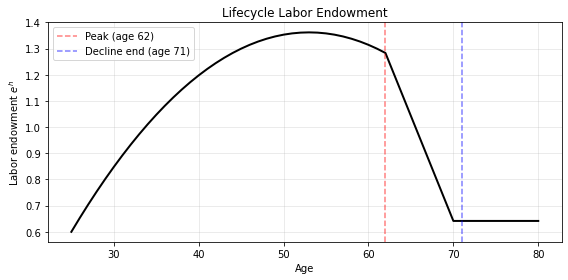

In [4]:
# Plot lifecycle labor endowment
ages = np.arange(25, 25 + A)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages, LABOR_ENDOW[0], 'k-', linewidth=2)
ax.axvline(x=25 + A_IS, color='r', linestyle='--', alpha=0.5, label=f'Peak (age {25+A_IS})')
ax.axvline(x=25 + A_DECR, color='b', linestyle='--', alpha=0.5, label=f'Decline end (age {25+A_DECR})')
ax.set_xlabel('Age')
ax.set_ylabel('Labor endowment $e^h$')
ax.set_title('Lifecycle Labor Endowment')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Firm with Adjustment Costs

### Production
$$Y_t = \xi_t K_t^\alpha L_t^{1-\alpha} + (1-\delta_t) K_t$$

### Prices
$$r_t = \alpha \xi_t K_t^{\alpha-1} L_t^{1-\alpha} + (1-\delta_t), \qquad w_t = (1-\alpha) \xi_t K_t^\alpha L_t^{-\alpha}$$

### Capital Adjustment Cost
$$\Psi^h = \frac{\zeta}{2} (k'^h - r \cdot k^h)^2$$

### Bond Payoff
$$\min(\kappa \cdot r, 1) \cdot b^h$$

In [5]:
def get_shocks(z, xi_tensor, delta_tensor):
    """Look up TFP and depreciation for shock index z."""
    tfp = tf.gather(xi_tensor, tf.cast(z, tf.int32))
    depr = tf.gather(delta_tensor, tf.cast(z, tf.int32))
    return tfp, depr


def firm_prices(K, L, tfp, depr):
    """Compute return on capital, wage, and aggregate output."""
    R = ALPHA * tfp * K**(ALPHA - 1.0) * L**(1.0 - ALPHA) + (1.0 - depr)
    w = (1.0 - ALPHA) * tfp * K**ALPHA * L**(-ALPHA)
    Y = tfp * K**ALPHA * L**(1.0 - ALPHA) + (1.0 - depr) * K
    return R, w, Y


print("Firm functions defined.")

Firm functions defined.


## 3. Network Architecture

### Input: 236 dimensions
$$\mathbf{x}_t = (z, \xi, \delta, K, L, R, w, Y, \; \text{fw}^{1:A}, \; \text{linc}^{1:A}, \; \text{inc}^{1:A}, \; k_{\text{wakeup}}^{1:A}, \; \pi^{1:4}) \in \mathbb{R}^{236}$$

where $236 = 8 + 4A + 4 = 8 + 224 + 4$.

### Output: 221 dimensions
$$\mathcal{N}_\theta(\mathbf{x}_t) = (k'^{1:55}, \; \lambda^{1:55}, \; q^{1:55}, \; \mu^{1:55}, \; p) \in \mathbb{R}^{221}, \qquad q^h = k'^h + \kappa b'^h$$

where $221 = 4(A-1) + 1$.

In [6]:
# Network dimensions
n_input  = 8 + 4 * A + NUM_SHOCKS  # = 236
n_output = 4 * (A - 1) + 1          # = 221

# Classroom: 128 hidden units (production: 1000)
n_hidden = 128

def build_network():
    """Build the policy network using Keras Functional API."""
    inputs = keras.Input(shape=(n_input,), name='state')
    x = keras.layers.Dense(n_hidden, activation='relu', name='hidden1')(inputs)
    x = keras.layers.Dense(n_hidden, activation='relu', name='hidden2')(x)
    outputs = keras.layers.Dense(n_output, activation='softplus', name='policy')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='OLG_benchmark')
    return model


nn = build_network()
nn.summary()

print(f"\nInput dim: {n_input}, Output dim: {n_output}")
print(f"Hidden units: {n_hidden} (production: 1000)")

Model: "OLG_benchmark"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 236)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 128)            │        30,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ policy (Dense)                  │ (None, 221)            │        28,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,357 (294.36 KB)

 Trainable params: 75,357 (294.36 KB)

 Non-trainable params: 0 (0.00 B)


Input dim: 236, Output dim: 221
Hidden units: 128 (production: 1000)


## 4. Output Decomposition

The 221-dimensional output is decomposed by slicing:

| Variable | Meaning | Indices | Count |
|----------|---------|---------|-------|
| $k'^h$ | Capital savings | $[0, 55)$ | 55 |
| $\lambda^h$ | Borrowing KKT mult. | $[55, 110)$ | 55 |
| $q^h = k'^h + \kappa b'^h$ | Collateral req. | $[110, 165)$ | 55 |
| $\mu^h$ | Collateral KKT mult. | $[165, 220)$ | 55 |
| $p$ | Bond price | $[220]$ | 1 |

In [7]:
def decompose_output(pred, m):
    """Decompose network output into economic variables.
    
    Args:
        pred: network output [batch, 221]
        m: batch size (tf int)
    
    Returns:
        kprime, lambd, coll_req, bprime, mu, p
    """
    kprime   = pred[:, 0 : A-1]            # Capital savings
    lambd    = pred[:, A-1 : 2*(A-1)]      # Borrowing multiplier
    coll_req = pred[:, 2*(A-1) : 3*(A-1)]  # Collateral requirement (k' + kappa*b')
    mu       = pred[:, 3*(A-1) : 4*(A-1)]  # Collateral multiplier
    p        = tf.reshape(pred[:, 4*(A-1)], [m, 1])  # Bond price
    
    # Bond holdings derived from collateral requirement
    bprime = (coll_req - kprime) / kappa_tf
    
    return kprime, lambd, coll_req, bprime, mu, p


print(f"Output decomposition:")
print(f"  k' (capital):       indices [0, {A-1})")
print(f"  lambda (borrow):    indices [{A-1}, {2*(A-1)})")
print(f"  coll_req:           indices [{2*(A-1)}, {3*(A-1)})")
print(f"  mu (collateral):    indices [{3*(A-1)}, {4*(A-1)})")
print(f"  p (bond price):     index [{4*(A-1)}]")


Output decomposition:
  k' (capital):       indices [0, 55)
  lambda (borrow):    indices [55, 110)
  coll_req:           indices [110, 165)
  mu (collateral):    indices [165, 220)
  p (bond price):     index [220]


## 5. State Construction and Simulation

In [8]:
@tf.function
def build_next_state_benchmark(nn_model, X_state, shock_idx):
    """Compute next-period extended state given current state and shock.

    Decorated with @tf.function: traced once per unique shock_idx value
    (4 traces total for shock_idx ∈ {0,1,2,3}), then runs as compiled graph.

    Returns:
        x_prime: next-period extended state [batch, 236]
        current_outputs: dict of current-period economic variables
    """
    eps = 1e-5
    m = tf.shape(X_state)[0]

    # Decompose current state
    z   = X_state[:, 0]
    R   = X_state[:, 5]  # Return on capital
    inc = X_state[:, 8 + 2*A : 8 + 3*A]       # Total income
    k_wakeup = X_state[:, 8 + 3*A : 8 + 4*A]  # Old capital

    # Get policy from network
    pred = nn_model(X_state)
    kprime, lambd, coll_req, bprime, mu, p = decompose_output(pred, m)
    p_mat = tf.tile(p, [1, A])

    # Wakeup capital and bonds (with newborn having 0)
    kprime_wakeup = tf.concat([START_CAP * tf.ones([m, 1]), kprime], axis=1)
    bprime_wakeup = tf.concat([tf.zeros([m, 1]), bprime], axis=1)

    # Saved amounts (oldest saves 0)
    k_saved = tf.concat([kprime, tf.zeros([m, 1])], axis=1)
    bond_spent = tf.multiply(tf.concat([bprime, tf.zeros([m, 1])], axis=1), p_mat)

    # Adjustment costs
    adjustment = k_saved - tf.reshape(R, [m, 1]) * k_wakeup
    adj_cost = (ZETA / 2.0) * adjustment**2

    # Consumption
    tot_saved = k_saved + bond_spent
    c_orig = inc - tot_saved - adj_cost
    c = tf.maximum(c_orig, eps * tf.ones_like(c_orig))

    # Aggregate capital tomorrow
    Kprime_orig = tf.reduce_sum(kprime, axis=1, keepdims=True)
    Kprime = tf.maximum(Kprime_orig, eps * tf.ones_like(Kprime_orig))

    # Next-period shock
    z_prime = float(shock_idx) * tf.ones([m], dtype=tf.float32)
    tfp_prime, depr_prime = get_shocks(z_prime, xi_tf, delta_tf)

    # Labor tomorrow
    l_prime = tf.gather(l_mat_tf, tf.cast(z_prime, tf.int32))
    L_prime = tf.reduce_sum(l_prime, axis=1, keepdims=True)

    # Prices tomorrow
    R_prime, w_prime, Y_prime = firm_prices(Kprime, L_prime, tfp_prime, depr_prime)
    R_prime_mat = R_prime * tf.ones([1, A])
    w_prime_mat = w_prime * tf.ones([1, A])

    # Financial wealth tomorrow
    fw_k_prime = kprime_wakeup * R_prime_mat
    bond_pay_prime = tf.minimum(kappa_tf * R_prime_mat, tf.ones_like(R_prime_mat))
    fw_b_prime = bprime_wakeup * bond_pay_prime
    fw_prime = fw_k_prime + fw_b_prime

    # Labor income tomorrow
    linc_prime = l_prime * w_prime_mat

    # Total income tomorrow
    inc_prime = fw_prime + linc_prime

    # Transition probabilities for next period
    pi_prime = tf.gather(pi_tf, tf.cast(z_prime, tf.int32))

    # Assemble next-period state
    x_prime = tf.concat([
        tf.expand_dims(z_prime, -1),
        tfp_prime, depr_prime,
        Kprime, L_prime, R_prime, w_prime, Y_prime,
        fw_prime, linc_prime, inc_prime,
        kprime_wakeup,
        pi_prime
    ], axis=1)

    return x_prime, {
        'kprime': kprime, 'bprime': bprime, 'lambd': lambd,
        'mu': mu, 'coll_req': coll_req, 'p': p,
        'c': c, 'c_orig': c_orig, 'k_saved': k_saved,
        'bond_spent': bond_spent, 'adj_cost': adj_cost,
        'adjustment': adjustment, 'Kprime_orig': Kprime_orig
    }


def simulate_episode(nn_model, x_start, episode_length):
    """Simulate an episode using batch simulation.

    Args:
        nn_model: policy network
        x_start: starting states [batch, 236]
        episode_length: number of steps per track

    Returns:
        X_data: [batch * episode_length, 236]
        x_end: ending states [batch, 236] for next episode
    """
    batch_size = x_start.shape[0]
    n_state = x_start.shape[1]

    X_data = np.zeros((batch_size * episode_length, n_state), dtype=np.float32)
    X_old = tf.constant(x_start)
    rand_num = np.random.rand(batch_size, episode_length)

    for t in range(episode_length):
        temp_rand = rand_num[:, t]
        X_new = np.zeros((batch_size, n_state), dtype=np.float32)

        # Get transition probabilities from state
        trans_probs = X_old[:, 8 + 4*A : 8 + 4*A + NUM_SHOCKS].numpy()
        cum_probs = np.cumsum(trans_probs, axis=1)

        for s in range(NUM_SHOCKS):
            if s == 0:
                mask = temp_rand <= cum_probs[:, 0]
            elif s < NUM_SHOCKS - 1:
                mask = (temp_rand > cum_probs[:, s-1]) & (temp_rand <= cum_probs[:, s])
            else:
                mask = temp_rand > cum_probs[:, s-1]

            if np.any(mask):
                x_prime_s, _ = build_next_state_benchmark(nn_model, X_old[mask], s)
                X_new[mask] = x_prime_s.numpy()

        X_data[t * batch_size : (t+1) * batch_size] = X_new
        X_old = tf.constant(X_new)

    x_end = X_data[-batch_size:]
    return X_data, x_end


print("Simulation functions defined (build_next_state_benchmark compiled with @tf.function).")

Simulation functions defined (build_next_state_benchmark compiled with @tf.function).


## 6. Complementarity and Cost Function

We have **two** complementarity conditions per agent:

1. **Borrowing:** $k'^h \geq 0$, $\lambda^h \geq 0$, $k'^h \cdot \lambda^h = 0$
2. **Collateral:** $k'^h + \kappa b'^h \geq 0$, $\mu^h \geq 0$, $(k'^h + \kappa b'^h) \cdot \mu^h = 0$

##### How the architecture handles the kink

Each KKT system has the form $a \geq 0,\ b \geq 0,\ a \cdot b = 0$. We split the
enforcement across the architecture and the loss:

- **Hard side (architecture):** the network outputs all non-negative quantities
  ($k'^h$, $\lambda^h$, $\mu^h$, and $q^h = k'^h + \kappa b'^h$) through a
  **softplus** activation. The inequalities $a \geq 0$ and $b \geq 0$ are then
  satisfied *by construction*, at every iteration of training.
- **Soft side (loss):** with $a, b \geq 0$ already guaranteed, the orthogonality
  condition $a \cdot b = 0$ reduces to a single squared residual. We push the
  raw product into the loss:
  $$\mathcal{L}_{\mathrm{KKT}} = \frac{1}{N}\sum \big[(k'^h\,\lambda^h)^2 + ((k'^h+\kappa b'^h)\,\mu^h)^2\big].$$
  This is the **same product form** used in the public reference code of
  Azinovic, Gaegauf and Scheidegger (2022) (`benchmark.py`). It works because
  softplus already eliminates the only ambiguous corner ($a, b < 0$), so the
  Fischer-Burmeister smoothing trick is not needed in this setting.

In short: softplus delivers feasibility for free; the product residual then
enforces complementarity in the loss, alongside the Euler residuals computed
below.

In [9]:
@tf.function
def compute_cost(X_batch, nn_model):
    """Compute the DEQN loss for the benchmark OLG model.
    
    Loss components:
    1. Euler equations for capital (55)
    2. Euler equations for bonds (55)
    3. KKT borrowing: k' * lambda (55)
    4. KKT collateral: coll_req * mu (55)
    5. Penalties: neg consumption, neg K, bond market clearing
    """
    eps = 1e-5
    m = tf.shape(X_batch)[0]
    
    # Current state decomposition
    z     = X_batch[:, 0]
    R_cur = X_batch[:, 5]
    inc   = X_batch[:, 8 + 2*A : 8 + 3*A]
    k_wakeup = X_batch[:, 8 + 3*A : 8 + 4*A]
    probs_next = X_batch[:, 8 + 4*A : 8 + 4*A + NUM_SHOCKS]
    
    # Current policy
    pred = nn_model(X_batch)
    kprime, lambd, coll_req, bprime, mu, p = decompose_output(pred, m)
    p_mat = tf.tile(p, [1, A])
    
    # Wakeup and saved amounts
    kprime_wakeup = tf.concat([START_CAP * tf.ones([m, 1]), kprime], axis=1)
    bprime_wakeup = tf.concat([tf.zeros([m, 1]), bprime], axis=1)
    k_saved = tf.concat([kprime, tf.zeros([m, 1])], axis=1)
    bond_spent = tf.multiply(tf.concat([bprime, tf.zeros([m, 1])], axis=1), p_mat)
    
    # Adjustment costs
    adjustment = k_saved - tf.reshape(R_cur, [m, 1]) * k_wakeup
    adj_cost = (ZETA / 2.0) * adjustment**2
    
    # Consumption
    tot_saved = k_saved + bond_spent
    c_orig = inc - tot_saved - adj_cost
    c = tf.maximum(c_orig, eps * tf.ones_like(c_orig))
    
    # Aggregate capital tomorrow
    Kprime_orig = tf.reduce_sum(kprime, axis=1, keepdims=True)
    Kprime = tf.maximum(Kprime_orig, eps * tf.ones_like(Kprime_orig))
    
    # Process all 4 future shocks
    all_c_orig_prime = []
    euler_cap_parts = []
    euler_bond_parts = []
    
    for s in range(NUM_SHOCKS):
        z_prime_s = float(s) * tf.ones([m], dtype=tf.float32)
        tfp_s, depr_s = get_shocks(z_prime_s, xi_tf, delta_tf)
        
        # Labor tomorrow
        l_prime_s = tf.gather(l_mat_tf, tf.cast(z_prime_s, tf.int32))
        L_prime_s = tf.reduce_sum(l_prime_s, axis=1, keepdims=True)
        
        # Prices tomorrow
        R_prime_s, w_prime_s, Y_prime_s = firm_prices(Kprime, L_prime_s, tfp_s, depr_s)
        R_prime_s_mat = R_prime_s * tf.ones([1, A])
        w_prime_s_mat = w_prime_s * tf.ones([1, A])
        
        # Wealth tomorrow
        fw_k_prime_s = kprime_wakeup * R_prime_s_mat
        bond_pay_s = tf.minimum(kappa_tf * R_prime_s_mat, tf.ones_like(R_prime_s_mat))
        fw_b_prime_s = bprime_wakeup * bond_pay_s
        fw_prime_s = fw_k_prime_s + fw_b_prime_s
        linc_prime_s = l_prime_s * w_prime_s_mat
        inc_prime_s = fw_prime_s + linc_prime_s
        
        # Transition probabilities for next-next period
        pi_prime_s = tf.gather(pi_tf, tf.cast(z_prime_s, tf.int32))
        
        # Build next-period state
        x_prime_s = tf.concat([
            tf.expand_dims(z_prime_s, -1),
            tfp_s, depr_s, Kprime, L_prime_s, R_prime_s, w_prime_s, Y_prime_s,
            fw_prime_s, linc_prime_s, inc_prime_s, kprime_wakeup, pi_prime_s
        ], axis=1)
        
        # Next-period policy
        pred_prime_s = nn_model(x_prime_s)
        kprime_prime_s = pred_prime_s[:, 0 : A-1]
        coll_req_prime_s = pred_prime_s[:, 2*(A-1) : 3*(A-1)]
        bprime_prime_s = (coll_req_prime_s - kprime_prime_s) / kappa_tf
        p_prime_s = tf.reshape(pred_prime_s[:, 4*(A-1)], [m, 1])
        p_prime_s_mat = tf.tile(p_prime_s, [1, A])
        
        # Next-period consumption
        k_saved_prime_s = tf.concat([kprime_prime_s, tf.zeros([m, 1])], axis=1)
        bond_spent_prime_s = tf.multiply(
            tf.concat([bprime_prime_s, tf.zeros([m, 1])], axis=1), p_prime_s_mat)
        adjustment_prime_s = k_saved_prime_s - tf.reshape(R_prime_s, [m, 1]) * kprime_wakeup
        adj_cost_prime_s = (ZETA / 2.0) * adjustment_prime_s**2
        
        c_orig_prime_s = inc_prime_s - k_saved_prime_s - bond_spent_prime_s - adj_cost_prime_s
        c_prime_s = tf.maximum(c_orig_prime_s, eps * tf.ones_like(c_orig_prime_s))
        all_c_orig_prime.append(c_orig_prime_s)
        
        # Euler capital: pi * R' * (1 + zeta * adj') * c'^(-gamma)
        pi_s = tf.expand_dims(probs_next[:, s], -1) * tf.ones([1, A-1])
        euler_cap_parts.append(
            pi_s * (R_prime_s_mat[:, 0:A-1] * (1.0 + ZETA * adjustment_prime_s[:, 1:A])) * \
            c_prime_s[:, 1:A] ** (-gamma_tf)
        )
        
        # Euler bond: pi * bond_pay' * c'^(-gamma)
        euler_bond_parts.append(
            pi_s * bond_pay_s[:, 0:A-1] * c_prime_s[:, 1:A] ** (-gamma_tf)
        )
    
    # Euler equations (relative error form)
    euler_cap_sum = euler_cap_parts[0] + euler_cap_parts[1] + euler_cap_parts[2] + euler_cap_parts[3]
    euler_bond_sum = euler_bond_parts[0] + euler_bond_parts[1] + euler_bond_parts[2] + euler_bond_parts[3]
    
    # Clamp denominators/numerators to avoid negative base for fractional exponent
    adj_denom = tf.maximum(1.0 + ZETA * adjustment[:, 0:A-1], eps)
    euler_cap_numer = tf.maximum(beta_tf * euler_cap_sum + lambd + mu, eps)
    
    opt_euler_cap = -1.0 + (
        (euler_cap_numer / adj_denom) ** (-1.0 / gamma_tf)
    ) / c[:, 0:A-1]
    
    euler_bond_numer = tf.maximum(beta_tf * euler_bond_sum + mu * kappa_tf, eps)
    p_denom = tf.maximum(p_mat[:, 0:A-1], eps)
    
    opt_euler_bond = -1.0 + (
        (euler_bond_numer / p_denom) ** (-1.0 / gamma_tf)
    ) / c[:, 0:A-1]
    
    opt_euler = tf.concat([opt_euler_cap, opt_euler_bond], axis=1)
    
    # KKT conditions
    opt_KKT_cap  = kprime * lambd           # k' * lambda = 0
    opt_KKT_bond = coll_req * mu            # (k' + kappa*b') * mu = 0
    opt_KKT = tf.concat([opt_KKT_cap, opt_KKT_bond], axis=1)
    
    # Penalties
    all_c_orig_all = tf.concat([c_orig] + all_c_orig_prime, axis=1)
    opt_punish_cons = (1.0 / eps) * tf.maximum(-all_c_orig_all, tf.zeros_like(all_c_orig_all))
    opt_punish_K = (1.0 / eps) * tf.maximum(-Kprime_orig, tf.zeros_like(Kprime_orig))
    
    # Bond market clearing
    tot_bond_dem = tf.reduce_sum(bprime, axis=1, keepdims=True)
    bond_dem_primes = []
    for s in range(NUM_SHOCKS):
        z_prime_s = float(s) * tf.ones([m], dtype=tf.float32)
        tfp_s, depr_s = get_shocks(z_prime_s, xi_tf, delta_tf)
        l_prime_s = tf.gather(l_mat_tf, tf.cast(z_prime_s, tf.int32))
        L_prime_s = tf.reduce_sum(l_prime_s, axis=1, keepdims=True)
        R_prime_s, w_prime_s, Y_prime_s = firm_prices(Kprime, L_prime_s, tfp_s, depr_s)
        R_prime_s_mat = R_prime_s * tf.ones([1, A])
        w_prime_s_mat = w_prime_s * tf.ones([1, A])
        fw_k_prime_s = kprime_wakeup * R_prime_s_mat
        bond_pay_s = tf.minimum(kappa_tf * R_prime_s_mat, tf.ones_like(R_prime_s_mat))
        fw_b_prime_s = bprime_wakeup * bond_pay_s
        fw_prime_s = fw_k_prime_s + fw_b_prime_s
        linc_prime_s = l_prime_s * w_prime_s_mat
        inc_prime_s = fw_prime_s + linc_prime_s
        pi_prime_s = tf.gather(pi_tf, tf.cast(z_prime_s, tf.int32))
        x_prime_s = tf.concat([
            tf.expand_dims(z_prime_s, -1),
            tfp_s, depr_s, Kprime, L_prime_s, R_prime_s, w_prime_s, Y_prime_s,
            fw_prime_s, linc_prime_s, inc_prime_s, kprime_wakeup, pi_prime_s
        ], axis=1)
        pred_prime_s = nn_model(x_prime_s)
        kpp_s = pred_prime_s[:, 0:A-1]
        crp_s = pred_prime_s[:, 2*(A-1):3*(A-1)]
        bpp_s = (crp_s - kpp_s) / kappa_tf
        bond_dem_primes.append(tf.reduce_sum(bpp_s, axis=1, keepdims=True))
    
    opt_bond_clear = tf.concat(
        [tot_bond_dem] + bond_dem_primes, axis=1)
    
    # Total loss
    combined = tf.concat([opt_euler, opt_punish_cons, opt_punish_K, opt_KKT, opt_bond_clear], axis=1)
    cost = tf.reduce_mean(combined ** 2)
    
    return cost, opt_euler_cap, opt_euler_bond, opt_KKT_cap, opt_KKT_bond


print("Cost function defined.")


Cost function defined.


## 7. Training

**Classroom settings (from slides):** 2,000 episodes, batch 64, lr $10^{-4}$, 1 epoch/ep
**Production settings:** 60,000 episodes, 1,000 hidden units, batch 64, lr $10^{-5}$

The training loop is identical to Notebook 7: simulate → mini-batch SGD → repeat.

> **Note on runtime:** Each episode simulates `sim_batch_size × sim_len` states using a
> parallel-track approach (more efficient than 07's sequential simulation). At classroom
> settings this takes ~20–30 min on CPU. The notebook below uses identical settings.

In [10]:
# Training hyperparameters
# NOTE: Classroom settings (slides): 2000 episodes, 128 hidden, lr=1e-4
#       Production settings:         60000 episodes, 1000 hidden, lr=1e-5
#       Smoke-test (this notebook):  100 episodes, 128 hidden, lr=1e-4
num_episodes    = 100         # Classroom: 2000, Production: 60000
sim_batch_size  = 100         # Parallel simulation tracks
sim_len         = 20          # Steps per track per episode
len_episodes    = sim_batch_size * sim_len   # = 2000 training states per episode
epochs_per_episode = 1
minibatch_size  = 64
learning_rate   = 1e-4        # Production: 1e-5

# Build fresh network and optimizer
nn = build_network()
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

np.random.seed(42)
tf.random.set_seed(42)


def create_initial_state(batch_size):
    """Create economically valid initial states to avoid NaN.

    Random states can produce NaN because CRRA exponents and
    adjustment cost terms require physically plausible values.
    """
    X = np.zeros((batch_size, n_input), dtype=np.float32)

    for i in range(batch_size):
        z = np.random.randint(NUM_SHOCKS)
        xi_val = XI[z, 0]
        delta_val = DELTA[z, 0]

        # Hump-shaped capital holdings (0 for newborn)
        k_wakeup = np.zeros(A, dtype=np.float32)
        for h in range(1, A):
            k_wakeup[h] = 0.15 * np.sin(np.pi * h / A) * (1.0 + 0.1 * np.random.randn())
        k_wakeup = np.maximum(k_wakeup, 0.0)

        K = max(np.sum(k_wakeup), 0.01)
        labor = LABOR_ENDOW[z]
        L = np.sum(labor)

        R = ALPHA * xi_val * K**(ALPHA - 1.0) * L**(1.0 - ALPHA) + (1.0 - delta_val)
        w = (1.0 - ALPHA) * xi_val * K**ALPHA * L**(-ALPHA)
        Y = xi_val * K**ALPHA * L**(1.0 - ALPHA) + (1.0 - delta_val) * K

        fw = k_wakeup * R
        linc = labor * w
        inc = fw + linc
        pi_row = PI[z]

        X[i] = np.concatenate([
            [z, xi_val, delta_val, K, L, R, w, Y],
            fw, linc, inc, k_wakeup, pi_row
        ])

    return X


X_start = create_initial_state(sim_batch_size)

print(f"Training: {num_episodes} episodes  (classroom: 2000, production: 60000)")
print(f"Simulation: {sim_batch_size} tracks × {sim_len} steps = {len_episodes} states/ep")
print(f"Mini-batch: {minibatch_size}, lr: {learning_rate}, hidden: {n_hidden}")

Training: 100 episodes  (classroom: 2000, production: 60000)
Simulation: 100 tracks × 20 steps = 2000 states/ep
Mini-batch: 64, lr: 0.0001, hidden: 128


In [11]:
@tf.function
def train_step(X_batch, nn_model, optimizer):
    """Single gradient update — compiled with @tf.function for speed."""
    with tf.GradientTape() as tape:
        loss, _, _, _, _ = compute_cost(X_batch, nn_model)
    grads = tape.gradient(loss, nn_model.trainable_variables)
    grads = [tf.clip_by_value(g, -1.0, 1.0) for g in grads]
    optimizer.apply_gradients(zip(grads, nn_model.trainable_variables))
    return loss

print("train_step compiled with @tf.function.")

train_step compiled with @tf.function.


In [12]:
# Training loop
cost_history = []
time_start = datetime.now()
n_batches = len_episodes // minibatch_size

X_data_train = X_start.copy()

for episode in range(num_episodes):
    # 1. Simulate episode
    X_episodes, X_data_train = simulate_episode(nn, X_data_train, sim_len)

    # 2. Train on this episode
    indices = np.random.permutation(len_episodes)
    epoch_cost = 0.0

    # First pass: compute cost (out-of-sample, no gradient)
    for b in range(n_batches):
        batch_idx = indices[b * minibatch_size : (b+1) * minibatch_size]
        X_batch = tf.constant(X_episodes[batch_idx])
        c, _, _, _, _ = compute_cost(X_batch, nn)
        epoch_cost += c.numpy() / n_batches

    cost_history.append(epoch_cost)

    # Second pass: gradient update via compiled @tf.function train_step
    for b in range(n_batches):
        batch_idx = indices[b * minibatch_size : (b+1) * minibatch_size]
        X_batch = tf.constant(X_episodes[batch_idx])
        train_step(X_batch, nn, optimizer)

    if episode % 50 == 0:
        elapsed = datetime.now() - time_start
        print(f"Episode {episode:5d} | log10(cost) = {np.log10(cost_history[-1]):.4f} | "
              f"time: {elapsed}")

print(f"\nTraining complete. Final log10(cost) = {np.log10(cost_history[-1]):.4f}")
print(f"Total time: {datetime.now() - time_start}")

Episode     0 | log10(cost) = 13.7842 | time: 0:00:13.011269


Episode    50 | log10(cost) = -1.2121 | time: 0:01:10.819111



Training complete. Final log10(cost) = -1.6399
Total time: 0:02:05.720209


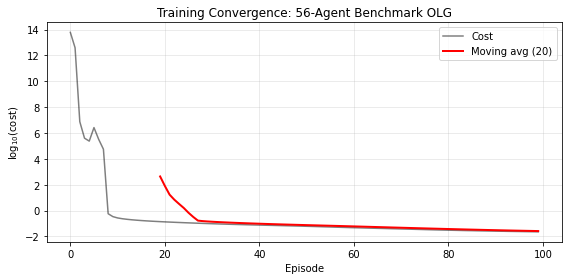

In [13]:
# Loss convergence plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.log10(cost_history), 'k-', alpha=0.5, label='Cost')

window = min(100, len(cost_history) // 5)
if window > 1:
    ma = np.convolve(np.log10(cost_history), np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(cost_history)), ma, 'r-', linewidth=2,
            label=f'Moving avg ({window})')

ax.set_xlabel('Episode')
ax.set_ylabel('log$_{10}$(cost)')
ax.set_title('Training Convergence: 56-Agent Benchmark OLG')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Policy Functions: Lifecycle Patterns

We simulate the trained model and examine lifecycle savings, bonds, and consumption.

In [14]:
# Reuse last episode's training data — no extra simulation needed
X_eval = X_episodes
m_eval = X_eval.shape[0]
X_eval_tf = tf.constant(X_eval)

# Get policy outputs
pred_eval = nn(X_eval_tf).numpy()

kprime_eval   = pred_eval[:, 0 : A-1]
lambd_eval    = pred_eval[:, A-1 : 2*(A-1)]
coll_req_eval = pred_eval[:, 2*(A-1) : 3*(A-1)]
mu_eval       = pred_eval[:, 3*(A-1) : 4*(A-1)]
p_eval        = pred_eval[:, 4*(A-1)].reshape(-1, 1)

bprime_eval = (coll_req_eval - kprime_eval) / KAPPA

# Get consumption and other variables
R_eval = X_eval[:, 5:6]
inc_eval = X_eval[:, 8 + 2*A : 8 + 3*A]
k_wakeup_eval = X_eval[:, 8 + 3*A : 8 + 4*A]

k_saved_eval = np.concatenate([kprime_eval, np.zeros((m_eval, 1))], axis=1)
p_mat_eval = np.tile(p_eval, [1, A])
bond_spent_eval = np.concatenate([bprime_eval, np.zeros((m_eval, 1))], axis=1) * p_mat_eval
adj_eval = k_saved_eval - R_eval * k_wakeup_eval
adj_cost_eval = (ZETA / 2.0) * adj_eval**2
c_eval = inc_eval - k_saved_eval - bond_spent_eval - adj_cost_eval

shock_eval = X_eval[:, 0].astype(int)

ages_plot = np.arange(25, 25 + A)
ages_except_last = np.arange(25, 25 + A - 1)

print(f"Evaluation data: {m_eval} states (last training episode)")

Evaluation data: 2000 states (last training episode)


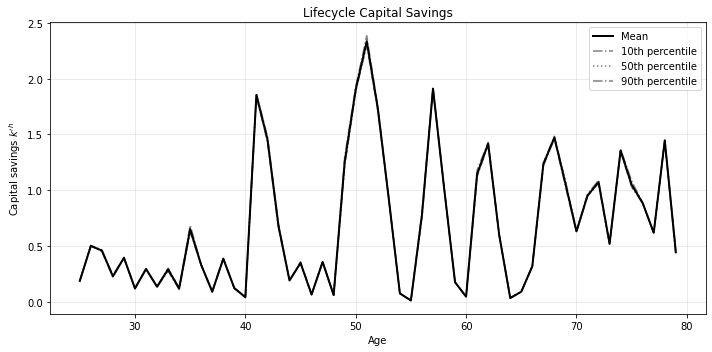

In [15]:
# Lifecycle capital savings by age
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ages_except_last, np.mean(k_saved_eval[:, :-1], axis=0), 'k-', linewidth=2, label='Mean')
for perc, ls in [(10, '-.'), (50, ':'), (90, '-.')]: 
    ax.plot(ages_except_last, np.percentile(k_saved_eval[:, :-1], perc, axis=0),
            f'k{ls}', alpha=0.5, label=f'{perc}th percentile')

ax.set_xlabel('Age')
ax.set_ylabel('Capital savings $k\'^h$')
ax.set_title('Lifecycle Capital Savings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

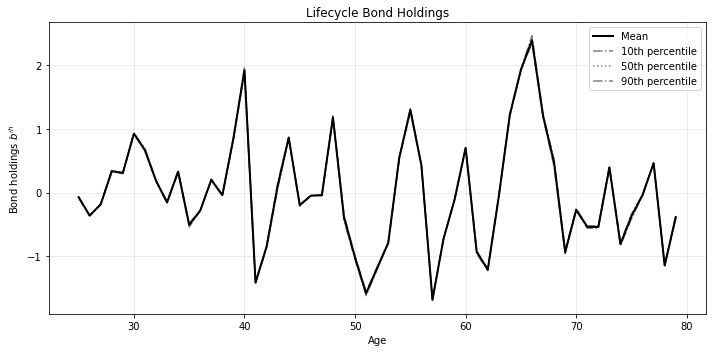

In [16]:
# Lifecycle bond holdings by age
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ages_except_last, np.mean(bprime_eval, axis=0), 'k-', linewidth=2, label='Mean')
for perc, ls in [(10, '-.'), (50, ':'), (90, '-.')]: 
    ax.plot(ages_except_last, np.percentile(bprime_eval, perc, axis=0),
            f'k{ls}', alpha=0.5, label=f'{perc}th percentile')

ax.set_xlabel('Age')
ax.set_ylabel('Bond holdings $b\'^h$')
ax.set_title('Lifecycle Bond Holdings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

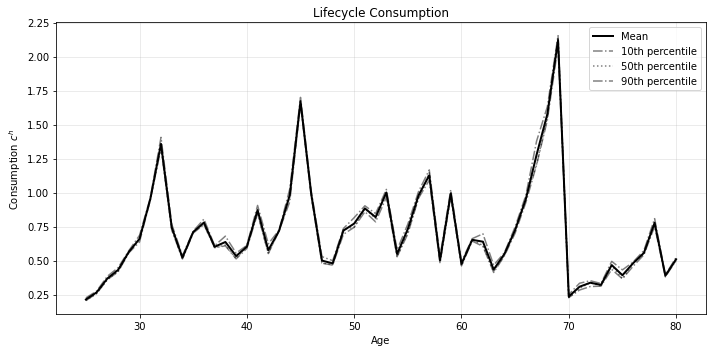

In [17]:
# Lifecycle consumption by age
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ages_plot, np.mean(c_eval, axis=0), 'k-', linewidth=2, label='Mean')
for perc, ls in [(10, '-.'), (50, ':'), (90, '-.')]: 
    ax.plot(ages_plot, np.percentile(c_eval, perc, axis=0),
            f'k{ls}', alpha=0.5, label=f'{perc}th percentile')

ax.set_xlabel('Age')
ax.set_ylabel('Consumption $c^h$')
ax.set_title('Lifecycle Consumption')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

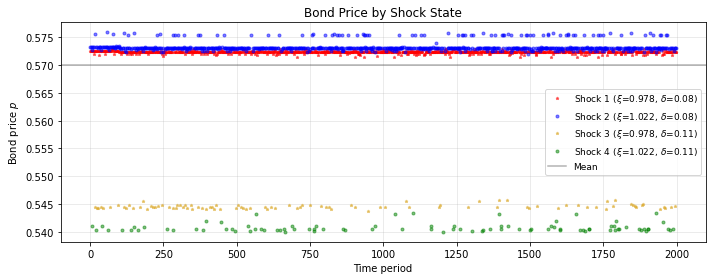

In [18]:
# Bond price by shock state
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['r', 'b', 'goldenrod', 'g']
markers = ['*', 'o', '*', 'o']
labels = [f'Shock {s+1} ($\\xi$={XI[s,0]:.3f}, $\\delta$={DELTA[s,0]:.2f})' for s in range(NUM_SHOCKS)]

for s in range(NUM_SHOCKS):
    mask = shock_eval == s
    if np.sum(mask) > 0:
        idx = np.where(mask)[0]
        ax.plot(idx, p_eval[mask, 0], markers[s], color=colors[s],
                markersize=3, alpha=0.5, label=labels[s])

ax.axhline(y=np.mean(p_eval), color='k', linestyle='-', alpha=0.3, label='Mean')
ax.set_xlabel('Time period')
ax.set_ylabel('Bond price $p$')
ax.set_title('Bond Price by Shock State')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

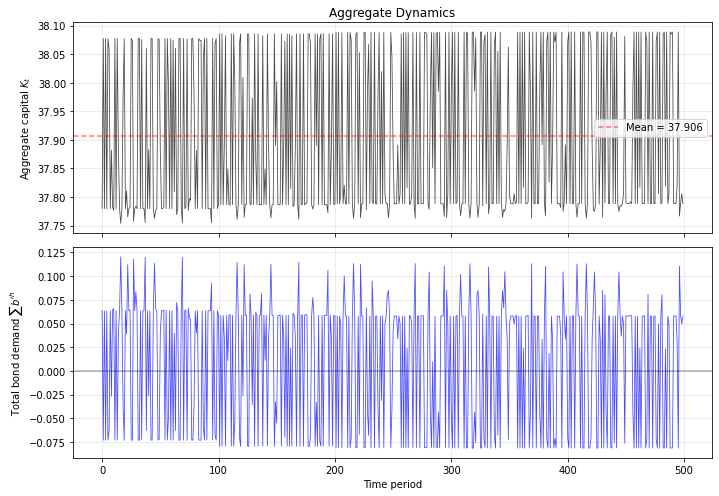

Aggregate capital: mean = 37.9061, std = 0.1380
Bond market clearing error: mean |sum b'| = 0.064479


In [19]:
# Aggregate dynamics: K and total bond demand
K_path = np.sum(kprime_eval, axis=1)
B_path = np.sum(bprime_eval, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(K_path[:500], 'k-', alpha=0.7, linewidth=0.8)
ax1.axhline(y=np.mean(K_path), color='r', linestyle='--', alpha=0.5,
            label=f'Mean = {np.mean(K_path):.3f}')
ax1.set_ylabel('Aggregate capital $K_t$')
ax1.set_title('Aggregate Dynamics')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(B_path[:500], 'b-', alpha=0.7, linewidth=0.8)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.set_xlabel('Time period')
ax2.set_ylabel('Total bond demand $\\sum b\'^h$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Aggregate capital: mean = {np.mean(K_path):.4f}, std = {np.std(K_path):.4f}")
print(f"Bond market clearing error: mean |sum b'| = {np.mean(np.abs(B_path)):.6f}")

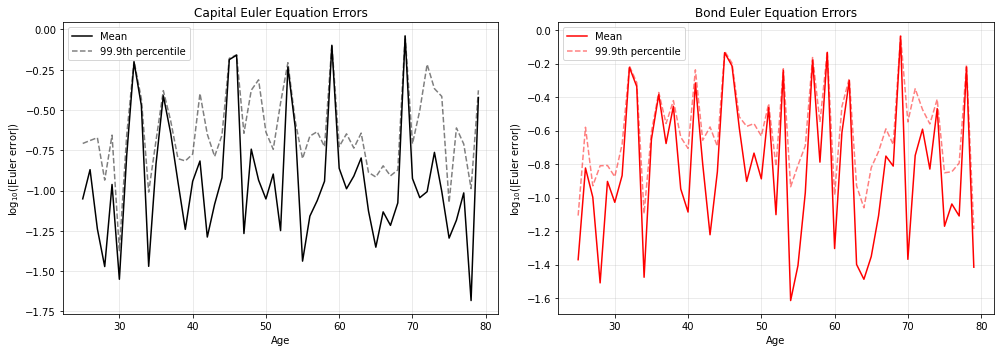


Accuracy Summary:
  Capital Euler: mean = 1.80e-01, max = 9.15e-01
  Bond Euler:    mean = 2.34e-01, max = 9.26e-01
  KKT capital:   mean = 7.38e-02
  KKT collateral: mean = 6.93e-02
  Bond MC:       mean = 6.45e-02


In [20]:
# Accuracy: Euler equation errors
# Compute Euler errors on evaluation data
_, euler_cap, euler_bond, kkt_cap, kkt_bond = compute_cost(X_eval_tf[:2000], nn)

euler_cap_np = np.abs(euler_cap.numpy())
euler_bond_np = np.abs(euler_bond.numpy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Capital Euler errors
ax1.plot(ages_except_last, np.log10(np.mean(euler_cap_np, axis=0) + 1e-15),
         'k-', label='Mean')
ax1.plot(ages_except_last, np.log10(np.percentile(euler_cap_np, 99.9, axis=0) + 1e-15),
         'k--', alpha=0.5, label='99.9th percentile')
ax1.set_xlabel('Age')
ax1.set_ylabel('log$_{10}$(|Euler error|)')
ax1.set_title('Capital Euler Equation Errors')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bond Euler errors
ax2.plot(ages_except_last, np.log10(np.mean(euler_bond_np, axis=0) + 1e-15),
         'r-', label='Mean')
ax2.plot(ages_except_last, np.log10(np.percentile(euler_bond_np, 99.9, axis=0) + 1e-15),
         'r--', alpha=0.5, label='99.9th percentile')
ax2.set_xlabel('Age')
ax2.set_ylabel('log$_{10}$(|Euler error|)')
ax2.set_title('Bond Euler Equation Errors')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAccuracy Summary:")
print(f"  Capital Euler: mean = {np.mean(euler_cap_np):.2e}, max = {np.max(euler_cap_np):.2e}")
print(f"  Bond Euler:    mean = {np.mean(euler_bond_np):.2e}, max = {np.max(euler_bond_np):.2e}")
print(f"  KKT capital:   mean = {np.mean(np.abs(kkt_cap.numpy())):.2e}")
print(f"  KKT collateral: mean = {np.mean(np.abs(kkt_bond.numpy())):.2e}")
print(f"  Bond MC:       mean = {np.mean(np.abs(B_path)):.2e}")

## Summary

We solved the benchmark 56-agent OLG model from Azinovic, Gaegauf & Scheidegger (2022) using Deep Equilibrium Nets:

1. **Model**: $A = 56$ agents, CRRA ($\gamma=2$), two assets (capital + bonds), borrowing and collateral constraints, adjustment costs, persistent Markov shocks
2. **Network**: Input(236) → Dense(128, ReLU) → Dense(128, ReLU) → Dense(221, softplus)
3. **Loss**: 55 capital Euler + 55 bond Euler + 55 borrowing KKT + 55 collateral KKT, plus bond-market-clearing and feasibility penalties
4. **Training**: 2,000 episodes (classroom-reduced from 60,000 production episodes)

### Key Takeaways
- The **same DEQN framework** from the 6-agent model (Notebook 7, `07_OLG_Analytic_DEQN`) scales to 56 agents
- Only the network size and training time change; the algorithm is unchanged
- Additional assets and constraints enter as **more output dimensions and loss terms**
- Complementarity is enforced with nonnegative outputs (softplus) plus KKT-product residuals for borrowing and collateral constraints

### Production vs. Classroom
The classroom version (128 hidden, 2,000 episodes) gives qualitatively correct lifecycle patterns but is not fully converged. The production version (1,000 hidden, 60,000+ episodes) achieves Euler errors $\sim 10^{-3}$.

### Next: Young's Method (Slide 07)
From **finitely many agents** (OLG) to a **continuum of agents** — tracking the wealth distribution as a histogram.

### References
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525
- Brumm, Kubler & Scheidegger (2017), *Advances in Economics and Econometrics* (World Congress)